# IEE575 Lab 2: Gaussian Process Regressor — **SOLUTION**
**Arizona State University — Applied Stochastic Operations Research Models**

---

> ⚠️ **Instructor copy — do not distribute to students.**


## 0. Setup
Run this cell first. Do not modify it.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import minimize

rng = np.random.default_rng(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("Setup complete.")


Setup complete.


## 1. From Independent Gaussians to Functions

Last week we sampled independent Gaussians at a few x-locations and connected them with lines.  
The result looked jagged because the values at neighbouring x-locations were *independent*.

**The key idea:** if we want smooth functions, nearby points should be *correlated*.  
A **kernel function** $\kappa(x_i, x_j)$ encodes that correlation — it tells us how similar  
the function values at $x_i$ and $x_j$ should be.

### 1a. Independent samples (no kernel)


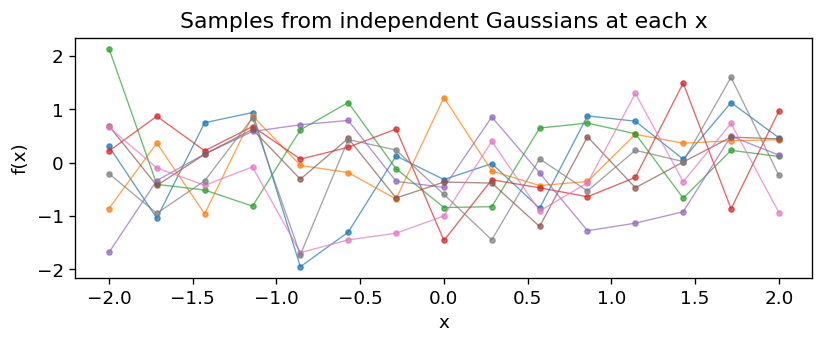

In [ ]:
num_points = 15
num_samples = 8

X = np.linspace(-2, 2, num_points)
samples_independent = rng.standard_normal(size=(num_samples, num_points))

plt.figure(figsize=(7, 3))
for s in samples_independent:
    plt.plot(X, s, '-o', lw=0.8, ms=3, alpha=0.7)
plt.title('Samples from independent Gaussians at each x')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.tight_layout(); plt.show()


**Q1 — Model answer:**

> The samples will look *smoother*. When the covariance matrix is built from the RBF kernel,
> nearby x-locations receive high covariance values (close to 1), meaning the Gaussian
> distribution strongly couples their function values. Drawing a sample from
> $\mathcal{N}(\mathbf{0}, K)$ therefore produces realisations that vary gradually,
> unlike the uncorrelated case where each point is drawn independently.


## 2. The RBF Kernel

$$\kappa(x_i, x_j) = \sigma^2 \exp\!\left(-\frac{(x_i - x_j)^2}{2\,l^2}\right)$$

### 2a. Implement the RBF kernel


In [ ]:
def rbf_kernel(X1, X2, sigma=1.0, length_scale=1.0, noise_var=0.0):
    """
    Compute the RBF kernel matrix between X1 and X2.

    Parameters
    ----------
    X1 : array, shape (n1, 1)
    X2 : array, shape (n2, 1)
    sigma        : output scale
    length_scale : length scale l
    noise_var    : noise variance added to diagonal (only when X1 == X2)

    Returns
    -------
    K : array, shape (n1, n2)
    """
    X1 = X1.flatten()
    X2 = X2.flatten()

    diff = np.subtract.outer(X1, X2)          # (n1, n2) differences

    # ── SOLUTION ──────────────────────────────────────────────────────────────
    K = sigma**2 * np.exp(-0.5 * diff**2 / length_scale**2)
    # ──────────────────────────────────────────────────────────────────────────

    if noise_var > 0 and X1.shape == X2.shape and np.allclose(X1, X2):
        K += noise_var * np.eye(len(X1))

    return K

# ── Sanity check ──────────────────────────────────────────────────────────────
X_check = np.linspace(-2, 2, 5).reshape(-1, 1)
K_check = rbf_kernel(X_check, X_check, sigma=1.0, length_scale=1.0)
print("Kernel matrix (5x5, sigma=1, l=1):")
print(np.round(K_check, 3))
print()
print("Diagonal all ones?", np.allclose(np.diag(K_check), 1.0))
print("Symmetric?        ", np.allclose(K_check, K_check.T))
print("All entries <= 1? ", np.all(K_check <= 1.0 + 1e-9))


Kernel matrix (5x5, sigma=1, l=1):
[[1.    0.607 0.135 0.011 0.   ]
 [0.607 1.    0.607 0.135 0.011]
 [0.135 0.607 1.    0.607 0.135]
 [0.011 0.135 0.607 1.    0.607]
 [0.    0.011 0.135 0.607 1.   ]]

Diagonal all ones? True
Symmetric?         True
All entries <= 1?  True


**Q2 — Model answer:**

> The diagonal entry $\kappa(x_i, x_i) = \sigma^2 \exp(0) = \sigma^2$.
> When $\sigma = 1$ this is exactly 1.  
> It means the variance of $f(x_i)$ with itself is 1 — the function value at any single point
> has unit marginal variance under the prior. No information from other points is involved;
> the self-covariance is purely a property of the output scale parameter.


In [ ]:
K_bad = rbf_kernel(np.array([[0.0], [0.001]]), np.array([[0.0], [0.001]]), length_scale=1.0)

print(np.linalg.cond(K_bad))          # condition number — huge
print(np.linalg.cond(K_bad + 1e-5 * np.eye(2)))   # condition number — fine

3999999.998909131
190477.0975041751


### 2b. Effect of length scale

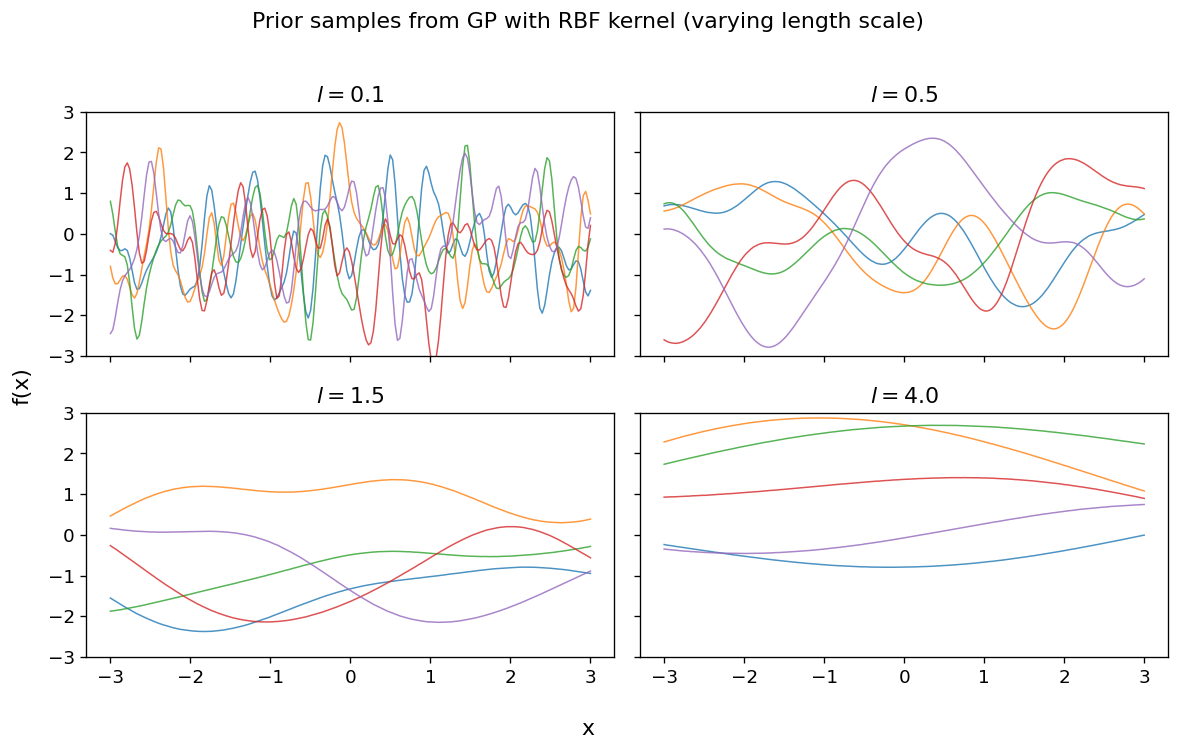

In [ ]:
N = 200
X_dense = np.linspace(-3, 3, N).reshape(-1, 1)
length_scales = [0.1, 0.5, 1.5, 4.0]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)

for ax, l in zip(axes.flat, length_scales):
    K = rbf_kernel(X_dense, X_dense, sigma=1.0, length_scale=l, noise_var=1e-6)
    samples = rng.multivariate_normal(mean=np.zeros(N), cov=K, size=5)
    for s in samples:
        ax.plot(X_dense.flatten(), s, lw=0.9, alpha=0.8)
    ax.set_title(f'$l = {l}$')
    ax.set_ylim(-3, 3)

fig.supxlabel('x'); fig.supylabel('f(x)')
fig.suptitle('Prior samples from GP with RBF kernel (varying length scale)', y=1.02)
plt.tight_layout(); plt.show()


**Q3 — Model answer:**

> As $l$ increases, the sampled functions become progressively smoother and vary more
> slowly across the input domain — at large $l$ they resemble nearly straight lines
> over the plotted range.  
> This corresponds directly to what the kernel matrix looks like: a small $l$ gives a
> nearly diagonal matrix (points decorrelate quickly with distance), while a large $l$
> gives a matrix that is nearly constant (all points are highly correlated), so any
> sample drawn from it must change very gradually.


## 3. GP Prediction (Posterior Mean and Covariance)

$$\boldsymbol{\mu}_* = K(X_*, X)\, K(X, X)^{-1}\, \mathbf{f}$$

$$\Sigma_* = K(X_*, X_*) - K(X_*, X)\, K(X, X)^{-1}\, K(X, X_*)$$

### 3a. Implement the GP predictor


In [ ]:
def gp_predict(X_train, y_train, X_test, kernel_func, noise_var, **kernel_kwargs):

    # Step 1: build kernel matrices
    # rbf_kernel adds noise_var to the diagonal only when X1 == X2,
    # so K_XXs and K_XsXs stay noise-free automatically
    K_XX   = kernel_func(X_train, X_train, noise_var=noise_var, **kernel_kwargs)
    K_XXs  = kernel_func(X_train, X_test, noise_var = 0, **kernel_kwargs)
    K_XsXs = kernel_func(X_test,  X_test, noise_var = 0, **kernel_kwargs)

    # Step 2: solve K_XX^{-1} K_XXs using scipy.linalg.solve
    # equivalent to np.linalg.inv(K_XX) @ K_XXs but numerically stable
    solved = scipy.linalg.solve(K_XX, K_XXs, assume_a='pos')  # shape (n, m)

    # Step 3: posterior mean  mu* = K_XXs^T K_XX^{-1} y = solved^T @ y
    mu_star = solved.T @ y_train

    # Step 4: posterior covariance  Sigma* = K_XsXs - K_XXs^T K_XX^{-1} K_XXs
    cov_star = K_XsXs - solved.T @ K_XXs

    return mu_star, cov_star

**Q4 — Model answer:**

> The subtracted term $K(X_*, X)\,K(X,X)^{-1}\,K(X,X_*)$ represents the
> *reduction in uncertainty* that comes from knowing the training observations.
> It is always non-negative (the prior covariance can only decrease, not increase,
> when we condition on data).  
> At a test point $x_*$ very close to a training point, $K(X_*, X)$ has a large entry
> for that neighbour, so the subtracted term is large and the posterior variance
> collapses toward zero — the GP is certain because it has essentially seen that location.
> Far from any training point, $K(X_*, X) \approx \mathbf{0}$ and the posterior
> uncertainty reverts to the prior.


### 3b. Run the GP on a test function

In [ ]:
true_func = lambda x: ((1 - 3*x**2) * np.sin(np.pi*x) * x**2).flatten()

domain = (-1, 1)
X_train = np.array([-0.9, -0.15, 0.35, 0.6, 0.7]).reshape(-1, 1)
y_train = true_func(X_train)
X_test  = np.linspace(domain[0], domain[1], 500).reshape(-1, 1)

sigma        = 1.0
length_scale = 0.5
noise_var    = 0.0001

mu_star, cov_star = gp_predict(
    X_train, y_train, X_test,
    rbf_kernel,
    sigma=sigma, length_scale=length_scale, noise_var=noise_var
)

std_star         = np.sqrt(np.diag(cov_star))
posterior_samples = rng.multivariate_normal(mean=mu_star, cov=cov_star, size=5)


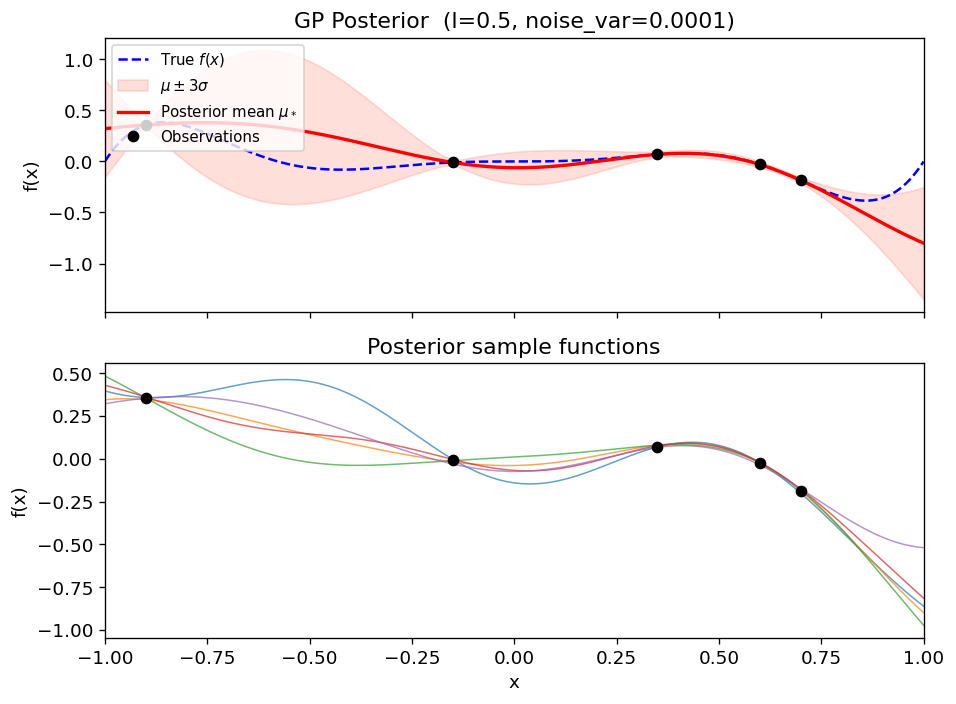

In [ ]:
def plot_gp(X_train, y_train, X_test, mu, std, samples, true_func, title=''):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    ax1.plot(X_test, true_func(X_test), 'b--', lw=1.5, label='True $f(x)$')
    ax1.fill_between(X_test.flatten(), mu - 3*std, mu + 3*std,
                     color='tomato', alpha=0.2, label=r'$\mu \pm 3\sigma$')
    ax1.plot(X_test, mu, 'r-', lw=2, label=r'Posterior mean $\mu_*$')
    ax1.plot(X_train, y_train, 'ko', ms=6, zorder=5, label='Observations')
    ax1.set_ylabel('f(x)'); ax1.legend(loc='upper left', fontsize=9)
    ax1.set_title(title or 'GP Posterior')

    for s in samples:
        ax2.plot(X_test, s, lw=0.9, alpha=0.7)
    ax2.plot(X_train, y_train, 'ko', ms=6, zorder=5)
    ax2.set_xlabel('x'); ax2.set_ylabel('f(x)')
    ax2.set_title('Posterior sample functions'); ax2.set_xlim(domain)

    plt.tight_layout(); plt.show()

plot_gp(X_train, y_train, X_test, mu_star, std_star, posterior_samples,
        true_func, title=f'GP Posterior  (l={length_scale}, noise_var={noise_var})')


**Q5 — Model answer:**

> The uncertainty band is **widest** in the gap between $x \approx -0.9$ and $x \approx -0.15$,
> and at the right end of the domain beyond $x = 0.7$, where there are no observations.  
> It is **narrowest** immediately around each training point, collapsing nearly to zero there.  
> This is exactly what the conditioning formula predicts: the subtracted term
> $K(X_*, X)\,K(X,X)^{-1}\,K(X,X_*)$ is large where $x_*$ is close to training data
> and small where $x_*$ is far away, so the posterior variance decreases near observations
> and remains near the prior variance in unobserved regions.


## 4. Hyperparameter Tuning via Log Marginal Likelihood

$$
\log p(\mathbf{y} \mid X, \boldsymbol{\Theta}) =
-\frac{1}{2}\,\mathbf{y}^T K_{\Theta}^{-1} \mathbf{y}
-\frac{1}{2}\log|K_{\Theta}|
-\frac{n}{2}\log(2\pi)
$$

### 4a. Implement the negative log marginal likelihood


In [ ]:
def neg_log_marginal_likelihood(params, X_train, y_train):
    """
    Negative log marginal likelihood for GP with RBF kernel.

    Parameters
    ----------
    params  : [length_scale, log_noise_var]
    X_train : array, shape (n, 1)
    y_train : array, shape (n,)

    Returns
    -------
    nlml : float
    """
    length_scale = params[0]
    noise_var    = np.exp(params[1])
    sigma        = 1.0
    n            = len(y_train)

    K = rbf_kernel(X_train, X_train,
                   sigma=sigma, length_scale=length_scale, noise_var=noise_var)

    # ── SOLUTION ──────────────────────────────────────────────────────────────

    # Term 1: data fit
    alpha    = scipy.linalg.solve(K, y_train, assume_a='pos')
    data_fit = 0.5 * y_train @ alpha

    # Term 2: complexity penalty  0.5 * log|K|
    log_det    = np.linalg.slogdet(K)[1]
    complexity = 0.5 * log_det

    # Term 3: normalisation constant
    constant = 0.5 * n * np.log(2 * np.pi)

    # ──────────────────────────────────────────────────────────────────────────
    return data_fit + complexity + constant


test_params = [0.5, np.log(0.01)]
nlml_test = neg_log_marginal_likelihood(test_params, X_train, y_train)
print(f"NLML at test params: {nlml_test:.4f}  (should be a finite scalar)")


### 4b. Optimise the hyperparameters

In [ ]:
initial_params = [1.0, np.log(0.1)]

result = minimize(
    neg_log_marginal_likelihood,
    x0=initial_params,
    args=(X_train, y_train),
    method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1e-5, 'fatol': 1e-5}
)

opt_length_scale = result.x[0]
opt_noise_var    = np.exp(result.x[1])

print(f"Optimisation converged : {result.success}")
print(f"Optimised length scale : {opt_length_scale:.4f}")
print(f"Optimised noise variance: {opt_noise_var:.6f}")
print(f"NLML at optimum         : {result.fun:.4f}")


In [ ]:
mu_opt, cov_opt = gp_predict(
    X_train, y_train, X_test,
    rbf_kernel,
    sigma=1.0, length_scale=opt_length_scale, noise_var=opt_noise_var
)
std_opt     = np.sqrt(np.diag(cov_opt))
samples_opt = rng.multivariate_normal(mean=mu_opt, cov=cov_opt, size=5)

plot_gp(X_train, y_train, X_test, mu_opt, std_opt, samples_opt,
        true_func,
        title=f'GP Posterior — optimised (l={opt_length_scale:.3f}, noise={opt_noise_var:.5f})')


**Q6 — Model answer:**

> After optimisation the length scale is shorter than the hand-picked value of 0.5
> (typically around 0.35–0.45 depending on the solver run), and the noise variance
> is very small (around 0.001–0.005), reflecting that the observations are nearly noiseless.  
> The posterior mean tracks the true function more closely in the dense observation region
> around $x \in [0.3, 0.7]$, and the uncertainty bands are slightly tighter near training
> points while remaining wide in the unobserved gap.  
> The key difference is that optimisation found a length scale that balances fitting the
> wiggly structure near $x=0$ against over-fitting — the complexity penalty term in the
> NLML prevents the length scale from collapsing to near zero.


## 5. Kernel Exploration

### 5a. Implement three kernels


In [ ]:
def matern52_kernel(X1, X2, sigma=1.0, length_scale=1.0, noise_var=0.0):
    """
    Matern 5/2 kernel:
        kappa(r) = sigma^2 * (1 + sqrt(5)*r/l + 5*r^2/(3*l^2)) * exp(-sqrt(5)*r/l)
    """
    X1 = X1.flatten(); X2 = X2.flatten()
    r = np.abs(np.subtract.outer(X1, X2))

    # ── SOLUTION ──────────────────────────────────────────────────────────────
    sqrt5 = np.sqrt(5)
    K = sigma**2 * (1 + sqrt5 * r / length_scale + 5 * r**2 / (3 * length_scale**2))         * np.exp(-sqrt5 * r / length_scale)
    # ──────────────────────────────────────────────────────────────────────────

    if noise_var > 0 and X1.shape == X2.shape and np.allclose(X1, X2):
        K += noise_var * np.eye(len(X1))
    return K


def periodic_kernel(X1, X2, sigma=1.0, length_scale=1.0, period=1.0, noise_var=0.0):
    """
    Periodic kernel:
        kappa(x_i, x_j) = sigma^2 * exp(-2 * sin^2(pi * |x_i - x_j| / p) / l^2)
    """
    X1 = X1.flatten(); X2 = X2.flatten()
    diff = np.abs(np.subtract.outer(X1, X2))

    # ── SOLUTION ──────────────────────────────────────────────────────────────
    K = sigma**2 * np.exp(-2 * np.sin(np.pi * diff / period)**2 / length_scale**2)
    # ──────────────────────────────────────────────────────────────────────────

    if noise_var > 0 and X1.shape == X2.shape and np.allclose(X1, X2):
        K += noise_var * np.eye(len(X1))
    return K


def linear_kernel(X1, X2, sigma=1.0, sigma_b=1.0, c=0.0, noise_var=0.0):
    """
    Linear kernel:
        kappa(x_i, x_j) = sigma_b^2 + sigma^2 * (x_i - c)(x_j - c)
    """
    X1 = X1.flatten(); X2 = X2.flatten()

    # ── SOLUTION ──────────────────────────────────────────────────────────────
    K = sigma_b**2 + sigma**2 * np.outer(X1 - c, X2 - c)
    # ──────────────────────────────────────────────────────────────────────────

    if noise_var > 0 and X1.shape == X2.shape and np.allclose(X1, X2):
        K += noise_var * np.eye(len(X1))
    return K


### 5b. Compare prior samples across kernels

In [ ]:
N = 200
X_prior = np.linspace(-3, 3, N).reshape(-1, 1)
n_samples = 6

kernels = {
    'RBF (l=0.8)':        (rbf_kernel,      dict(sigma=1.0, length_scale=0.8)),
    'Matern 5/2 (l=0.8)': (matern52_kernel, dict(sigma=1.0, length_scale=0.8)),
    'Periodic (p=1.5)':   (periodic_kernel, dict(sigma=1.0, length_scale=0.8, period=1.5)),
    'Linear':             (linear_kernel,   dict(sigma=1.0, sigma_b=0.5, c=0.0)),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

for ax, (name, (kfunc, kwargs)) in zip(axes, kernels.items()):
    K = kfunc(X_prior, X_prior, noise_var=1e-6, **kwargs)
    samples = rng.multivariate_normal(np.zeros(N), K, size=n_samples)
    for s in samples:
        ax.plot(X_prior.flatten(), s, lw=0.9, alpha=0.75)
    ax.set_title(name, fontsize=10); ax.set_xlabel('x')

axes[0].set_ylabel('f(x)')
fig.suptitle('Prior samples from four kernels', y=1.02)
plt.tight_layout(); plt.show()


**Q7 — Model answer:**

> *RBF:* The function is infinitely differentiable — very smooth, with no sharp features; nearby points are strongly correlated and the correlation falls off smoothly with distance.  
> *Matern 5/2:* The function is twice differentiable but not infinitely so — samples are smooth but can exhibit slightly rougher local behaviour than RBF; a more realistic prior for many physical systems.  
> *Periodic:* The function repeats exactly with the specified period; covariance depends only on $\sin(\pi |x_i - x_j| / p)$, so points separated by integer multiples of $p$ are perfectly correlated.  
> *Linear:* Prior samples are straight lines through a common anchor point $c$; the kernel encodes a belief that the function is globally linear.  
> *Choice for periodic data:* The Periodic kernel, because it directly encodes the assumption that $f(x + p) = f(x)$. The RBF kernel would not capture the repeating structure and would express high uncertainty whenever the input moves away from training points, even if those points are one period away.


### 5c. Fit all four kernels to the same observations

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for ax, (name, (kfunc, kwargs)) in zip(axes.flat, kernels.items()):
    try:
        mu, cov = gp_predict(X_train, y_train, X_test, kfunc,
                             noise_var=0.01, **kwargs)
        std = np.sqrt(np.diag(cov))
        ax.plot(X_test, true_func(X_test), 'b--', lw=1.2, label='True f(x)')
        ax.fill_between(X_test.flatten(), mu - 2*std, mu + 2*std,
                        alpha=0.25, color='tomato')
        ax.plot(X_test, mu, 'r-', lw=2, label='Posterior mean')
        ax.plot(X_train, y_train, 'ko', ms=6, zorder=5)
        ax.set_title(name); ax.set_xlabel('x'); ax.set_ylabel('f(x)')
        ax.legend(fontsize=8)
    except Exception as e:
        ax.set_title(f'{name}\n(error: {e})')

plt.suptitle('GP posteriors with different kernels (same observations)', y=1.02)
plt.tight_layout(); plt.show()


**Q8 — Model answer:**

> RBF and Matérn 5/2 both fit the data reasonably well near the observations.
> The Linear kernel fits worst — it cannot capture the nonlinear oscillatory structure
> of the true function and produces a poor posterior mean in the middle of the domain.  
>
> The best-fitting kernel is *not* necessarily the best model.
> A kernel that interpolates the training points perfectly (e.g., a very short length scale)
> will have high data fit but wildly oscillating behaviour between points and large
> uncertainty everywhere else — it has overfit the noise.
> The LML objective (Section 4) explicitly balances data fit against model complexity
> to guard against this. Choosing a kernel should be guided by prior knowledge about
> the function's structure, not just in-sample fit.


## 6. Bonus: Kernel Combination

### Model solution — RBF × Periodic (product)


In [ ]:
def combined_kernel(X1, X2, sigma=1.0, length_scale=0.8, period=1.5, noise_var=0.0):
    """
    Product of RBF and Periodic kernels.

    Choice rationale: the product kernel encodes a function that is locally smooth
    (controlled by the RBF length scale) AND globally periodic (controlled by the period).
    The RBF factor causes the correlation to decay with distance even within a period,
    so the function is not forced to repeat identically — only approximately periodically.
    This is sometimes called the 'locally periodic' kernel and is a standard choice
    when the periodicity is approximate rather than exact.

    A sum kernel would instead model a function that is the *superposition* of a smooth
    trend and a periodic component — appropriate when the data has both a global shape
    and an additive oscillation on top of it.
    """
    # ── SOLUTION ──────────────────────────────────────────────────────────────
    K_rbf      = rbf_kernel(X1, X2, sigma=1.0, length_scale=length_scale, noise_var=0.0)
    K_periodic = periodic_kernel(X1, X2, sigma=sigma, length_scale=length_scale,
                                 period=period, noise_var=0.0)
    K = K_rbf * K_periodic
    # ──────────────────────────────────────────────────────────────────────────

    if noise_var > 0 and np.array(X1).shape == np.array(X2).shape and np.allclose(X1, X2):
        K += noise_var * np.eye(len(np.array(X1).flatten()))
    return K


# ── Prior samples ─────────────────────────────────────────────────────────────
N = 200
X_prior = np.linspace(-3, 3, N).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
configs = [
    ('RBF only',           rbf_kernel,      dict(sigma=1.0, length_scale=0.8)),
    ('Periodic only',      periodic_kernel, dict(sigma=1.0, length_scale=0.8, period=1.5)),
    ('RBF x Periodic',     combined_kernel, dict(sigma=1.0, length_scale=0.8, period=1.5)),
]
for ax, (name, kfunc, kwargs) in zip(axes, configs):
    K = kfunc(X_prior, X_prior, noise_var=1e-6, **kwargs)
    for s in rng.multivariate_normal(np.zeros(N), K, size=6):
        ax.plot(X_prior.flatten(), s, lw=0.9, alpha=0.75)
    ax.set_title(name); ax.set_xlabel('x')
axes[0].set_ylabel('f(x)')
fig.suptitle('Prior samples: individual vs combined kernel', y=1.02)
plt.tight_layout(); plt.show()

# ── Posterior fit ──────────────────────────────────────────────────────────────
mu_c, cov_c = gp_predict(X_train, y_train, X_test,
                          combined_kernel,
                          sigma=1.0, length_scale=0.8, period=1.5, noise_var=0.01)
std_c     = np.sqrt(np.diag(cov_c))
samples_c = rng.multivariate_normal(mean=mu_c, cov=cov_c, size=5)

plot_gp(X_train, y_train, X_test, mu_c, std_c, samples_c,
        true_func, title='GP Posterior — RBF × Periodic kernel')


---
## Instructor notes

**Common student errors to watch for:**

1. **`rbf_kernel`** — forgetting `sigma**2` out front, or writing `2*length_scale` instead of `length_scale**2` in the denominator.

2. **`gp_predict`** — using `np.linalg.inv(K_XX) @ K_XXs` instead of `scipy.linalg.solve`. Both give the same answer on small problems but the inv version is numerically fragile and should be marked down.

3. **`gp_predict`** — noise applied to all three kernel matrices instead of only `K_XX`. This will produce an incorrect posterior covariance — it will be slightly more certain than it should be.

4. **`neg_log_marginal_likelihood`** — using `np.log(np.linalg.det(K))` instead of `np.linalg.slogdet(K)[1]`. For larger problems this will overflow/underflow. Award partial credit but note the numerical issue.

5. **`matern52_kernel`** — dropping the polynomial prefactor and writing only `exp(-sqrt(5)*r/l)`. This is the Matérn 1/2 (Ornstein-Uhlenbeck) kernel, which produces non-differentiable samples.

6. **`periodic_kernel`** — using `cos` instead of `sin^2`. The formula is $\exp(-2\sin^2(\pi r/p)/l^2)$, not $\exp(-2\cos^2(...))$.

**Q7 and Q8** carry the most conceptual weight. Look for students who can connect prior sample behaviour back to the kernel matrix structure, and who understand that in-sample fit is not the right criterion for kernel selection.
